#Insert initial arguments

In [229]:
#Enter the following parameters
tcga_set = 'TCGA_breast'
gdc_file_name = 'gdc_sample_sheet.2022-06-16.tsv'
normal_tissue_type = 'normal gbm_brain tissue'
tumor_type = 'TCGA_breast'
tissue_type = 'TCGA_breast'

slide_file_location = f'drive/My Drive/Colab Notebooks/MSc/data_sets/{tcga_set}/slide.tsv'
gdc_file_location = f'drive/My Drive/Colab Notebooks/MSc/data_sets/{tcga_set}/{gdc_file_name}'
results_output_file = f'drive/My Drive/Colab Notebooks/MSc/data_sets/{tcga_set}/results'

#Import modules

In [230]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [231]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Reading the data

In [232]:
#Cell composition data from TCGA BRCA slides

cols_to_use = ['case_id',
              'case_submitter_id',
              'sample_id',
              'sample_submitter_id',
              'percent_lymphocyte_infiltration',
              'percent_monocyte_infiltration',
              'percent_necrosis',
              'percent_neutrophil_infiltration',
              'percent_normal_cells',
              'percent_stromal_cells',
              'percent_tumor_cells',
              'percent_tumor_nuclei']


cell_composition = pd.read_csv(f'{slide_file_location}', sep = '\t', na_values = "'--", usecols = cols_to_use)
cell_composition.head(4)

,case_id,case_submitter_id,sample_id,sample_submitter_id,percent_lymphocyte_infiltration,percent_monocyte_infiltration,percent_necrosis,percent_neutrophil_infiltration,percent_normal_cells,percent_stromal_cells,percent_tumor_cells,percent_tumor_nuclei
0,3afa1e93-1df8-4e4c-aaa4-557463f4bb77,TCGA-A7-A0DA,4f441e61-6bea-4a12-841d-def270804bbe,TCGA-A7-A0DA-01A,2.0,0.0,3.0,0.0,20.0,47.0,30.0,75.0
1,3afa1e93-1df8-4e4c-aaa4-557463f4bb77,TCGA-A7-A0DA,6d250ffa-8365-4c5a-90ee-fa7f447a6071,TCGA-A7-A0DA-01Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3afa1e93-1df8-4e4c-aaa4-557463f4bb77,TCGA-A7-A0DA,6d250ffa-8365-4c5a-90ee-fa7f447a6071,TCGA-A7-A0DA-01Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,b379bfb8-284e-4300-8325-85cfd6809cb8,TCGA-BH-A0BD,399c4e0a-ff1e-4411-a34a-094ab290197d,TCGA-BH-A0BD-01Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [233]:
#Data gdc sample sheet information

gdc = pd.read_csv(f'{gdc_file_location}', sep = '\t')
gdc.head(4)

,File ID,File Name,Data Category,Data Type,Project ID,Case ID,Sample ID,Sample Type
0,d796de5e-4512-4b3a-93d4-2a006e79084f,da752364-731c-4e77-8d6e-9c91a5b7f68f.rna_seq.a...,Transcriptome Profiling,Gene Expression Quantification,TCGA-BRCA,TCGA-E2-A1L7,TCGA-E2-A1L7-11A,Solid Tissue Normal
1,104e3cb5-c6df-422b-a55f-6b19408594d4,2056c543-2f73-4a2f-995e-3af2dda7b514.rna_seq.a...,Transcriptome Profiling,Gene Expression Quantification,TCGA-BRCA,TCGA-E2-A1L7,TCGA-E2-A1L7-01A,Primary Tumor
2,4bb6eb79-4256-4b19-b158-883da969a582,90950125-1b6b-499d-97e2-5d6b78b3e6fe.rna_seq.a...,Transcriptome Profiling,Gene Expression Quantification,TCGA-BRCA,TCGA-AR-A0U0,TCGA-AR-A0U0-01A,Primary Tumor
3,e267a6fb-3d15-4658-b464-25438bd41330,48c63209-a387-4045-8a24-7b9792db7623.rna_seq.a...,Transcriptome Profiling,Gene Expression Quantification,TCGA-BRCA,TCGA-BH-A28O,TCGA-BH-A28O-01A,Primary Tumor


#Dictionaries

In [234]:
#Dictionary with sample ID for keys and sample type as values

sample_id_sample_type = {}
for sample in gdc['Sample ID']:
  sample_type = gdc.loc[gdc['Sample ID'] == sample, 'Sample Type']
  sample_id_sample_type[sample] = sample_type.iloc[0]


#Merging cell composition and tumor types

In [235]:
#Creating series with tissue type information for each sample

tissue_types = []
for i in cell_composition['sample_submitter_id']:
  if i in sample_id_sample_type.keys():
    single_sample_type = sample_id_sample_type[i]
    tissue_types.append(single_sample_type)
  else:
    tissue_types.append('unknown')
tissue_types = pd.Series(tissue_types)


In [236]:
cell_composition['tissue_type'] = tissue_types
cell_composition.drop(cell_composition[cell_composition['tissue_type'] == 'unknown'].index, inplace = True)
cell_composition.head(4)

,case_id,case_submitter_id,sample_id,sample_submitter_id,percent_lymphocyte_infiltration,percent_monocyte_infiltration,percent_necrosis,percent_neutrophil_infiltration,percent_normal_cells,percent_stromal_cells,percent_tumor_cells,percent_tumor_nuclei,tissue_type
0,3afa1e93-1df8-4e4c-aaa4-557463f4bb77,TCGA-A7-A0DA,4f441e61-6bea-4a12-841d-def270804bbe,TCGA-A7-A0DA-01A,2.0,0.0,3.0,0.0,20.0,47.0,30.0,75.0,Primary Tumor
4,b379bfb8-284e-4300-8325-85cfd6809cb8,TCGA-BH-A0BD,832b8766-0e59-4ad4-b4c9-1e39b2ce4fb1,TCGA-BH-A0BD-01A,7.0,0.0,1.0,0.0,5.0,19.0,75.0,85.0,Primary Tumor
5,b379bfb8-284e-4300-8325-85cfd6809cb8,TCGA-BH-A0BD,832b8766-0e59-4ad4-b4c9-1e39b2ce4fb1,TCGA-BH-A0BD-01A,5.0,0.0,1.0,0.0,12.0,12.0,75.0,85.0,Primary Tumor
7,22eaba28-be67-4730-9846-860bc1fca29a,TCGA-A8-A0AB,860baf5b-abcf-4014-8b4b-d0a4b0d15c51,TCGA-A8-A0AB-01A,5.0,1.0,5.0,0.0,15.0,50.0,30.0,60.0,Primary Tumor


#Visualization

In [237]:
normal_samples = cell_composition[cell_composition['tissue_type'] == 'Solid Tissue Normal']
tumor_samples = cell_composition[cell_composition['tissue_type'] != 'Solid Tissue Normal']

In [238]:
df = tumor_samples[['percent_lymphocyte_infiltration',	'percent_monocyte_infiltration',	'percent_necrosis',	'percent_neutrophil_infiltration',	'percent_normal_cells',	'percent_stromal_cells',	'percent_tumor_cells']]
df = df.melt()
df.replace({'percent_lymphocyte_infiltration': 'lymphocytes',
            'percent_monocyte_infiltration' : 'monocytes',
            'percent_necrosis' : 'necrotic cells',
            'percent_neutrophil_infiltration' : 'neutrophils',
            'percent_normal_cells' : 'normal cells',
            'percent_stromal_cells' : 'stromal cells',
            'percent_tumor_cells' : 'tumor cells'}, inplace = True)
df.rename(columns = {'variable':'cell_type', 'value':'percentage'}, inplace = True)
df

,cell_type,percentage
0,lymphocytes,2.0
1,lymphocytes,7.0
2,lymphocytes,5.0
3,lymphocytes,5.0
4,lymphocytes,5.0
...,...,...
11391,tumor cells,35.0
11392,tumor cells,90.0
11393,tumor cells,70.0
11394,tumor cells,100.0


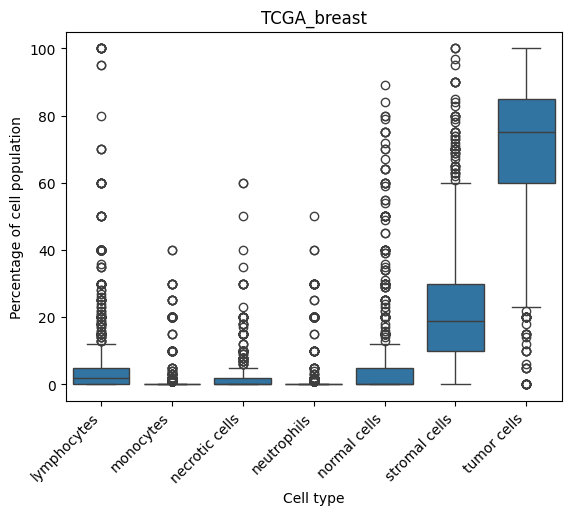

In [239]:
sns.boxplot(data = df, x = 'cell_type', y = 'percentage')
plt.xticks(rotation = 45, horizontalalignment = 'right')
plt.xlabel('Cell type')
plt.ylabel('Percentage of cell population')
plt.title(tissue_type)
plt.savefig(f'{results_output_file}/boxplot_{tissue_type}.svg', bbox_inches = 'tight')